# 02 — Retrieval A/B Testing and Automatic Plots

This notebook runs retrieval-only benchmarking across all configured profiles and generates comparison plots automatically.

Profiles come from `scripts.config.RETRIEVAL_PROFILES`, including:
- `bm25_only`
- `dense_only`
- `dense_rerank`
- `hybrid`
- `hybrid_rerank`

Recommended order:
1. run `01_data_ingestion_and_chunking.ipynb`
2. run this notebook
3. continue to `03_model_comparison_and_evaluation.ipynb`


In [1]:

from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\aminl\Desktop\PORTFOLIO Projects\final list - V2\aegis-rag-v4


In [2]:

from scripts.config import (
    EVAL_DIR,
    PLOTS_DIR,
    RESULTS_ABLATION_FILE,
    RETRIEVAL_PROFILES,
)
import scripts.eval as eval_mod

retrieval_gold = eval_mod.load_json(EVAL_DIR / "retrieval_gold.json")
qa_gold = eval_mod.load_json(EVAL_DIR / "qa_gold.json")

print("retrieval_gold examples:", len(retrieval_gold))
print("qa_gold examples:", len(qa_gold))
print("profiles:", list(RETRIEVAL_PROFILES.keys()))


retrieval_gold examples: 20
qa_gold examples: 20
profiles: ['bm25_only', 'dense_only', 'hybrid', 'hybrid_rerank']


## Run retrieval A/B testing

In [3]:

ablation_results = [
    eval_mod.evaluate_retrieval_profile(retrieval_gold, profile_name)
    for profile_name in RETRIEVAL_PROFILES.keys()
]

eval_mod.save_json(ablation_results, RESULTS_ABLATION_FILE)
eval_mod.plot_retrieval_profiles(ablation_results, PLOTS_DIR)

ablation_df = pd.DataFrame([
    {"profile_name": item["profile_name"], **item["aggregate"]}
    for item in ablation_results
]).sort_values(["ndcg@5", "recall@5"], ascending=False)

print("Saved ablation results →", RESULTS_ABLATION_FILE)
ablation_df


Saved ablation results → C:\Users\aminl\Desktop\PORTFOLIO Projects\final list - V2\aegis-rag-v4\data\eval\results_ablation.json


,profile_name,recall@5,recall@10,ndcg@5,mrr,qps,avg_latency_sec
3,hybrid_rerank,0.850000,0.85,0.800158,0.825000,14.741474,0.067836
1,dense_only,0.766667,0.90,0.728674,0.792500,18.031013,0.055460
0,bm25_only,0.766667,0.85,0.721374,0.770833,7110.352670,0.000141
2,hybrid,0.850000,0.85,0.689476,0.695833,18.712444,0.053440


## Generated plots

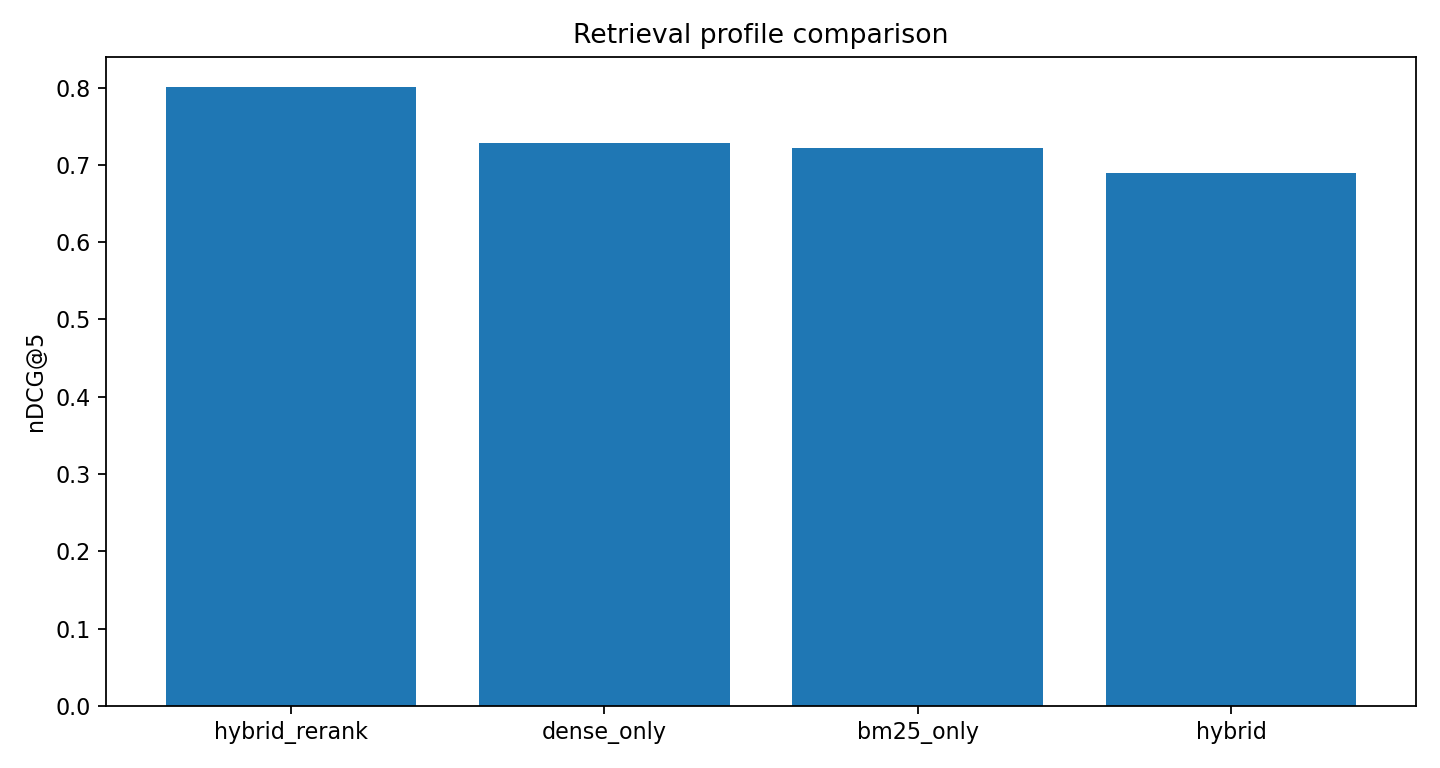

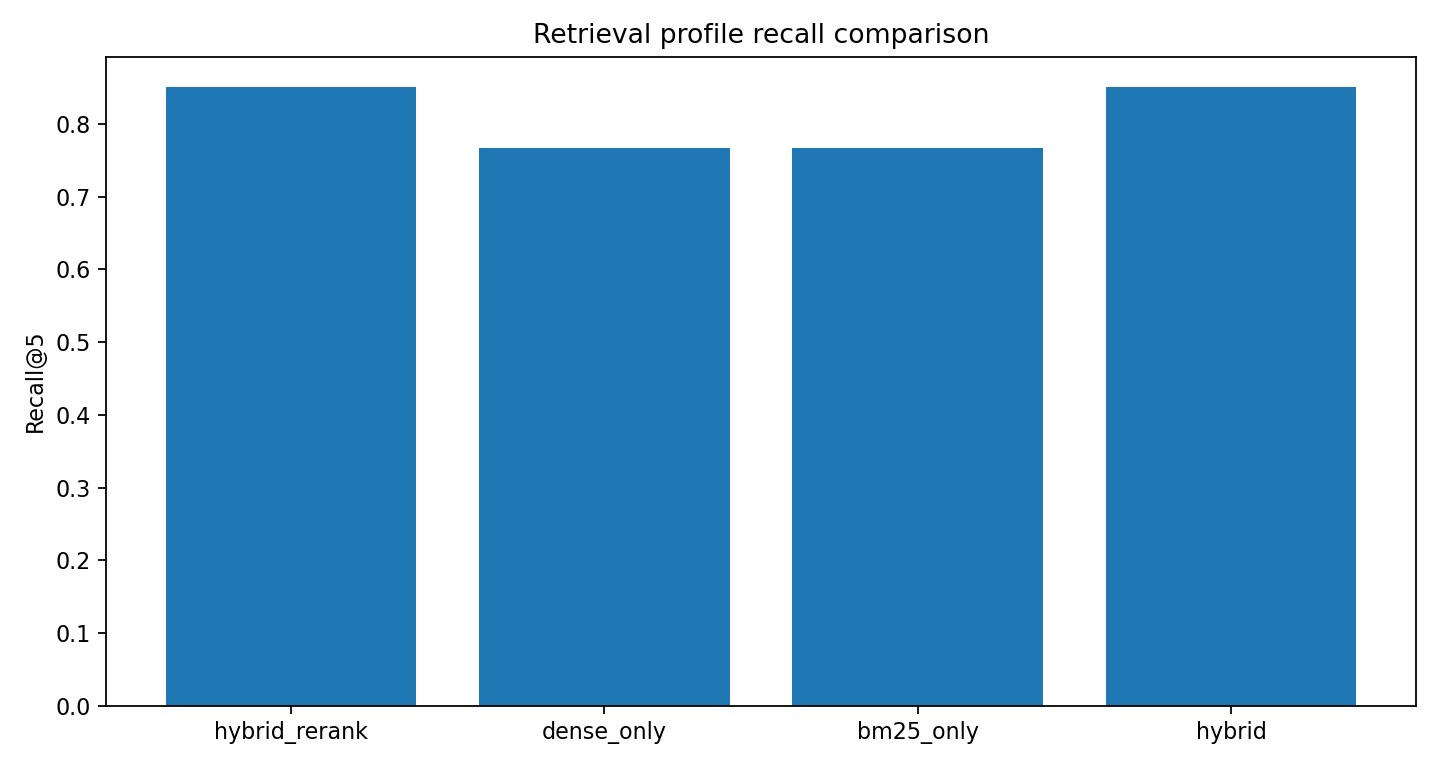

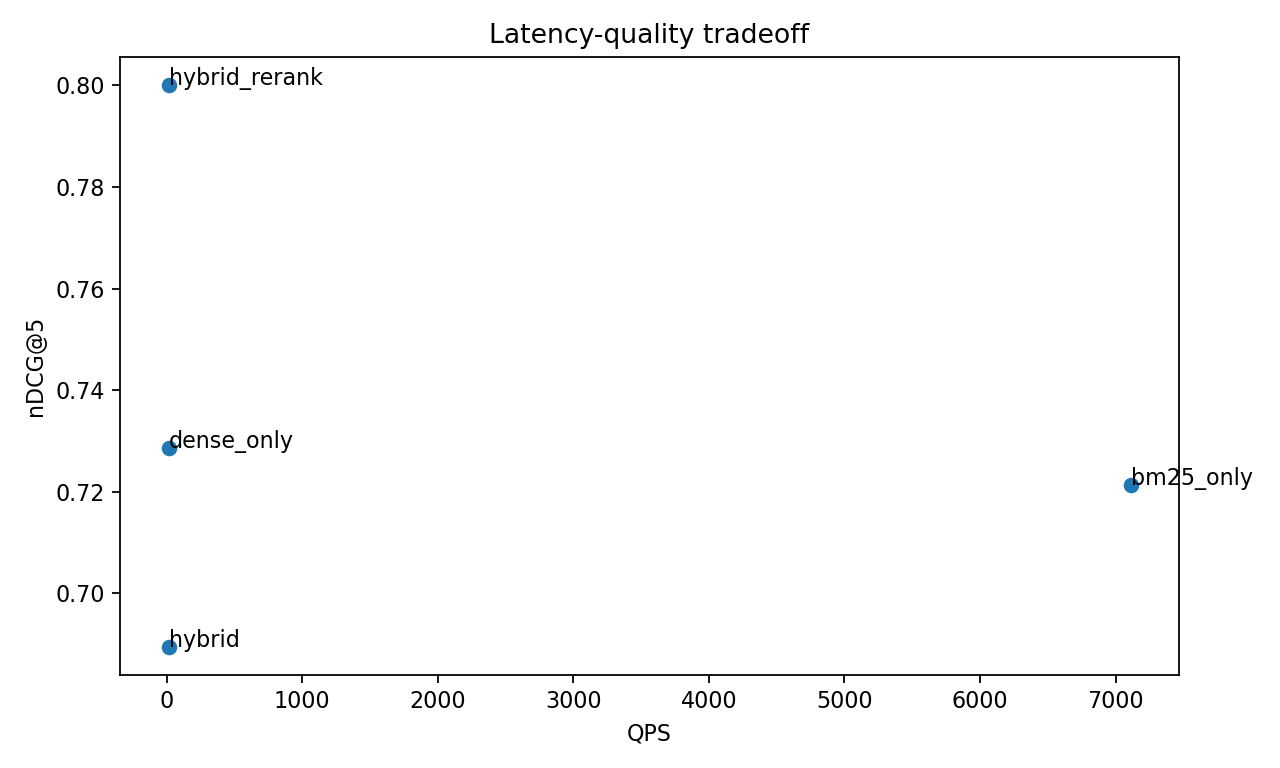

In [4]:

display(Image(filename=str(PLOTS_DIR / "retrieval_profile_ndcg.png")))
display(Image(filename=str(PLOTS_DIR / "retrieval_profile_recall.png")))
display(Image(filename=str(PLOTS_DIR / "latency_quality_tradeoff.png")))


## Inspect one profile in detail

In [5]:

best_profile = ablation_df.iloc[0]["profile_name"]
profile_detail = next(x for x in ablation_results if x["profile_name"] == best_profile)

print("Best profile:", best_profile)
pd.DataFrame(profile_detail["per_query"])[
    ["query", "recall@5", "ndcg@5", "mrr", "retrieved_ids", "relevant_ids"]
].head(10)


Best profile: hybrid_rerank


,query,recall@5,ndcg@5,mrr,retrieved_ids,relevant_ids
0,What time is standard check-in?,0.666667,0.383649,0.25,[15_Security_and_After-Hours_Access_Policy_p1_...,"[01_Guest_Stay_and_Incidentals_Handbook_p1_c1,..."
1,Can I check in at noon for free?,1.000000,0.852928,1.00,[08_Corporate_Stay_FAQ_for_Sponsored_Guests_p1...,"[01_Guest_Stay_and_Incidentals_Handbook_p1_c1,..."
2,How much is self-parking?,1.000000,1.000000,1.00,"[03_Ground_Transportation,_Parking,_and_Person...","[01_Guest_Stay_and_Incidentals_Handbook_p2_c1,..."
3,Is valet parking free for all guests?,1.000000,0.919721,1.00,"[01_Guest_Stay_and_Incidentals_Handbook_p2_c1,...","[01_Guest_Stay_and_Incidentals_Handbook_p2_c1,..."
4,What is the late checkout fee?,0.333333,0.469279,1.00,[08_Corporate_Stay_FAQ_for_Sponsored_Guests_p1...,"[01_Guest_Stay_and_Incidentals_Handbook_p1_c1,..."
5,Can I stay after 2 PM without paying?,1.000000,1.000000,1.00,"[01_Guest_Stay_and_Incidentals_Handbook_p1_c1,...",[01_Guest_Stay_and_Incidentals_Handbook_p1_c1]
6,Are pets allowed and what is the fee?,0.000000,0.000000,0.00,"[05_Guest_Safety,_Accessibility,_and_Reasonabl...",[]
7,Do service animals pay a fee?,1.000000,1.000000,1.00,[08_Corporate_Stay_FAQ_for_Sponsored_Guests_p1...,"[05_Guest_Safety,_Accessibility,_and_Reasonabl..."
8,What are quiet hours?,1.000000,1.000000,1.00,"[01_Guest_Stay_and_Incidentals_Handbook_p1_c2,...",[01_Guest_Stay_and_Incidentals_Handbook_p1_c2]
9,Is smoking allowed on balconies?,1.000000,1.000000,1.00,"[01_Guest_Stay_and_Incidentals_Handbook_p1_c2,...","[01_Guest_Stay_and_Incidentals_Handbook_p1_c2,..."


## Quick qualitative retrieval check

In [6]:

from scripts.retriever import HybridRetriever

test_query = "Can a sponsored guest arrive at noon?"
for profile_name in RETRIEVAL_PROFILES.keys():
    retriever = HybridRetriever(profile_name=profile_name)
    docs, diagnostics = retriever.retrieve_with_diagnostics(test_query)
    print(f"\nPROFILE: {profile_name}")
    print("rewritten_query:", diagnostics.get("rewritten_query"))
    print("routed_group   :", diagnostics.get("routed_group"))
    print("chunk_ids      :", [d.metadata["chunk_id"] for d in docs[:5]])



PROFILE: bm25_only
rewritten_query: can a sponsored guest arrive at noon?
routed_group   : guest_stay
chunk_ids      : ['08_Corporate_Stay_FAQ_for_Sponsored_Guests_p2_c1', '08_Corporate_Stay_FAQ_for_Sponsored_Guests_p1_c1', '02_Hosted_Travel_and_Accommodation_Policy_p2_c1', '01_Guest_Stay_and_Incidentals_Handbook_p1_c1', '05_Guest_Safety,_Accessibility,_and_Reasonable_Comfort_Standard_p2_c1']

PROFILE: dense_only
rewritten_query: can a sponsored guest arrive at noon?
routed_group   : guest_stay
chunk_ids      : ['08_Corporate_Stay_FAQ_for_Sponsored_Guests_p1_c1', '02_Hosted_Travel_and_Accommodation_Policy_p2_c1', '01_Guest_Stay_and_Incidentals_Handbook_p1_c1', '09_Early_Arrival_and_Inventory_Management_Policy_p1_c1', '08_Corporate_Stay_FAQ_for_Sponsored_Guests_p2_c1']

PROFILE: hybrid
rewritten_query: can a sponsored guest arrive at noon?
routed_group   : guest_stay
chunk_ids      : ['08_Corporate_Stay_FAQ_for_Sponsored_Guests_p1_c1', '02_Hosted_Travel_and_Accommodation_Policy_p2_c1',

## Next notebook

Continue with `03_model_comparison_and_evaluation.ipynb` to evaluate the full RAG pipeline with the target production profile and inspect failure cases.
